# Exploration of R3D data computed with full polarisation matrices in kappa

## Extra codes

e.g. Create gas-kappa-file with empty scatmat-matrix

In [ ]:
# Write empty kappascatmat-file for usage for gas
# or other medium with no scattering.

import analyze_polarization_functions as apf
apf.write_r3d_emptypolarization()


## Test code for plotting each polarisation component

See Radmc3d-manual for info on polarisation. 

> radmc3d image stokes

Gives image.out-files with 4 columns of pixel data, ie 4 images in each file in the following order:

- I : Total intensity. the incident light
- Q : describes linear polarisation (horizontal or vertical, depending on the sign).
- U : describes polarisation at a 2nd set of orthogonal axes (+/-45 degrees)
- V : describes elliptical polarisation (right-handed if > 0, left-handed < 0)

R3d uses IAU 1974 definition as described in Hamaker & Bregman (1996) A&AS 117, pp.161. (see manual sect 6.9.1 Definitions ...).

All polarised light combines into I via

> I^2 = Q^2 + U^2 + V^2

Only linear polarised light is defined as the complex statement

> L = Q + iU

so that the absolute is (ie the INTENSITY of the LINEAR polarised light)

> |L| = sqrt(Q^2 + U^2)

and the INTENSITY of the CIRCULAR polarised light is simply

> |V| = sqrt(V^2)


All total fluxes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


/tmp/ipykernel_49487/3594298831.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


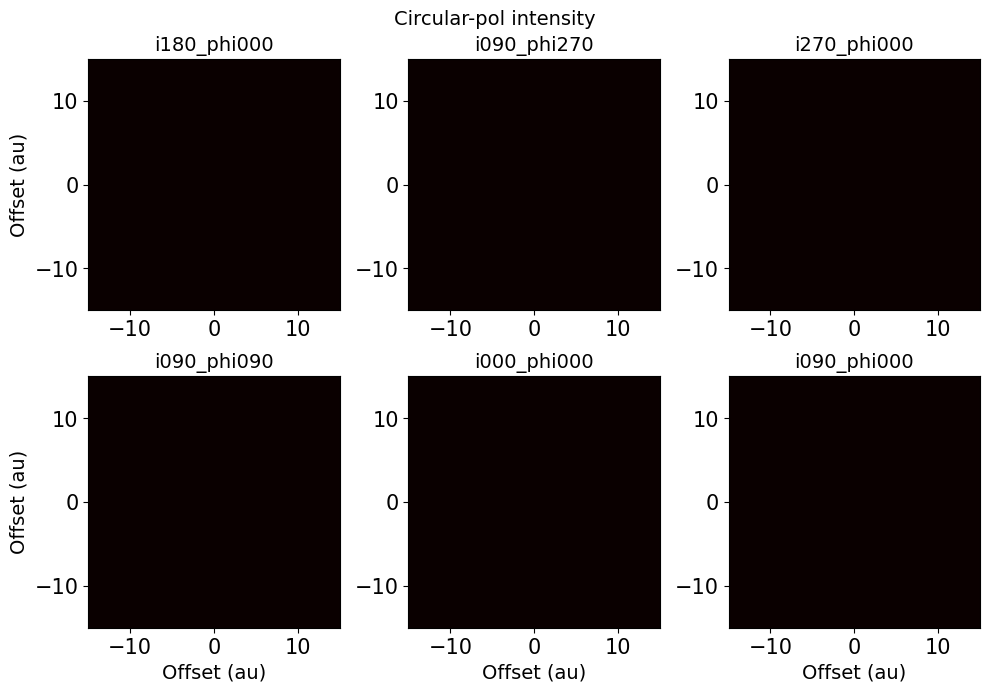

In [ ]:
# Plot all images of one polarization and at one snapshot
# and one wavelenght only
#
import analyze_polarization_functions as apf
fig,ax,fluxtotal = apf.plot_onepolarization(
    imagewave=0.82,
    polarization='i'
    #polarization='l'
    #polarization='v'
)
print(f'All total fluxes: {fluxtotal}')

fig.set_figheight(7)
fig.set_figwidth(10)
fig.tight_layout()
fig.subplots_adjust(top=0.92)
fig.show()

In [ ]:
# Plot all polarizations of one angle
# one snapshot, one wavelength
# 
#  TODO
# 


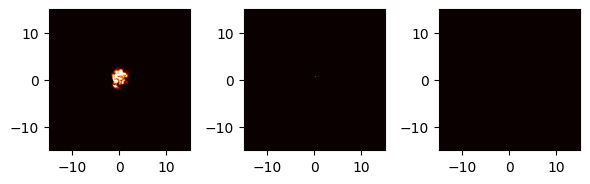

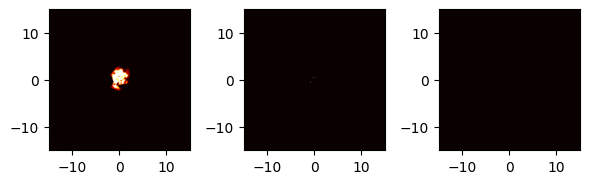

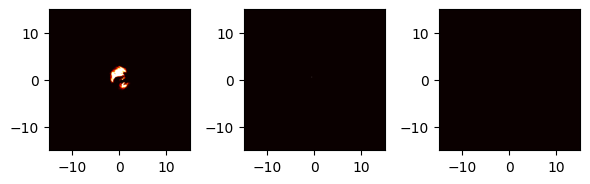

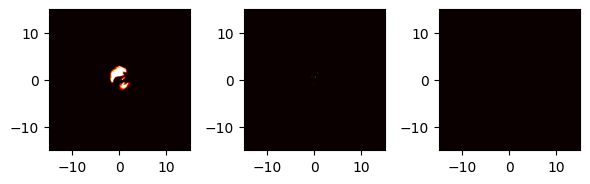

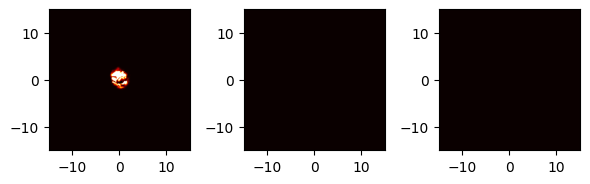

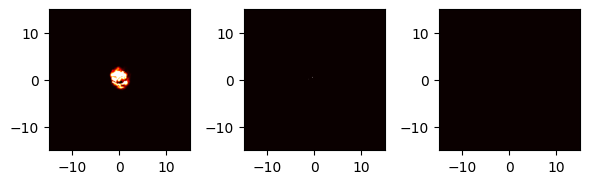

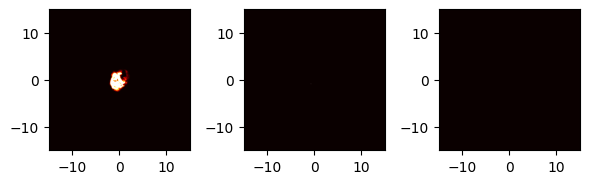

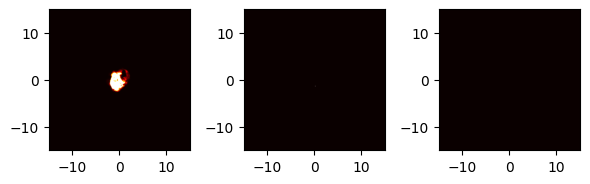

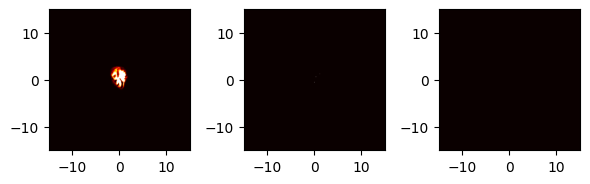

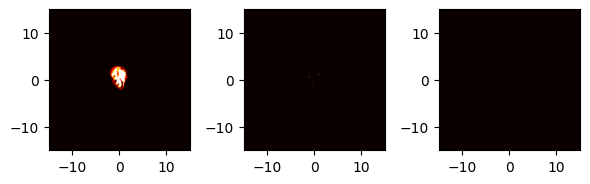

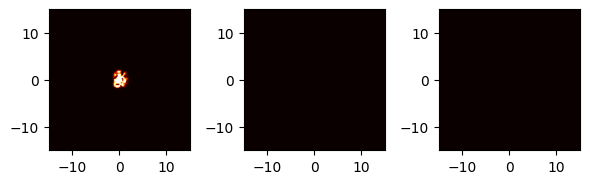

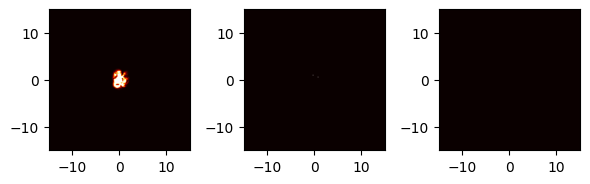

In [ ]:
# plot all polarizations in subplots
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt
import numpy as np

# Useful numbers
c = 2.998e8 # speed of light in m/s
pc = 30.857e15 # 1 parsec in m
AUcm = 1.49598e13 # AU in cm
kboltz = 1.3806503e-23 # Boltzmann constant in Si
hplanck = 6.626068e-34 # Planck constant in Si

# Definitions
path = '../r3dresults/st28gm06n052_nospikes/166_optoolmgsio/'




images = [
    'image_i000_phi000_0.65um.out',
    'image_i000_phi000_0.82um.out',
    'image_i090_phi000_0.65um.out',
    'image_i090_phi000_0.82um.out',
    'image_i090_phi090_0.65um.out',
    'image_i090_phi090_0.82um.out',
    'image_i090_phi270_0.65um.out',
    'image_i090_phi270_0.82um.out',
    'image_i180_phi000_0.65um.out',
    'image_i180_phi000_0.82um.out',
    'image_i270_phi000_0.65um.out',
    'image_i270_phi000_0.82um.out',
]

for nimage,image in enumerate(images):

    distance = 1

    # List polarisations
    polarisation = [
        'Tot intensity',
        'Linear intensity',
        'Circular intensity',
    ]
    # Declare lists for image intensity, linear pol intensity and circ pol intensity
    I_intens_1d = []
    L_intens_1d = []
    V_intens_1d = []
    # Place holder for total flux density
    fluxtotal = []
    # Declare image object
    fig,ax = plt.subplots(
        1,3,
        num=nimage,
        dpi=100
    )
    # Load image
    #
    # Automatically add / to end of path if it's missing
    if path[-1] != '/':
        path += '/'
    #
    # Declare lists
    image1d = []
    # Load data
    with open(path+image, 'r') as f:
        for nl,line in enumerate(f.readlines()):

            # Check if polarised image or not
            if nl == 0:
                imagesetting = int(line.strip())
            if imagesetting == 3:
                # This is correct, otherwise, load normal image
                #            
                # Row 1: image size, pixels by pixels
                if nl == 1:
                    npixels_x = int(line.split()[0])
                    npixels_y = int(line.split()[1])
                    npixels = max([npixels_x,npixels_y])            
                # row 3: pixel size is in cm, divide by AUcm for AU
                if nl == 3:
                    pixelsize_au = float(line.split()[0])/AUcm


                # row 6 onward: pixel-values, four columns
                # image.out's pixels has unit
                # erg s-1 cm-2 Hz-1 ster-1
                if nl > 5:
                    if len(line.split()) > 1:
                        # Loop over polarisation numbers
                        # Split line and extract each column, strip from \n and make floats
                        i_pixeldata = float(line.split()[0].strip())
                        q_pixeldata = float(line.split()[1].strip())
                        u_pixeldata = float(line.split()[2].strip())
                        v_pixeldata = float(line.split()[3].strip())
                        # Save each image-combo
                        I_intens_1d.append(
                            i_pixeldata
                        )
                        L_intens_1d.append(
                            np.sqrt(q_pixeldata**2 + u_pixeldata**2)
                        )
                        V_intens_1d.append(
                            np.sqrt(v_pixeldata**2)
                        )
    if imagesetting == 1:
        raise ValueError('Not polarised, load normal image with a3d.load_images()!')
    else:
        # Continue with plotting image
        #
        # Extract some useful quantities
        # pixel size in asec (pixelsize in au and distance in pc gives distance in asec)
        pixelsize_as = pixelsize_au / distance
        #
        # Size of whole image in AU and image-axis-scales
        size_au = pixelsize_au * npixels
        axisplot  = [-0.5*size_au,0.5*size_au,-0.5*size_au,0.5*size_au]
        #
        # Total flux density of the image in Jy
        # Transoform to Jy/pix and sum all
        # 1 Jy = 1e23 erg/(s cm2 Hz)
        # 1 asec = 1/(180/pi * 3600)^2 ster = 2.35044305391e-11 ster
        # 1 pixel = pixelsize_as^2  asec^2
        #totalflux = sum(image1d) * 1.e23 * 2.35044305391e-11 * pixelsize_as**2
        #
        # Create 2D arrays
        I_image2d = np.zeros((npixels,npixels))
        L_image2d = np.zeros((npixels,npixels))
        V_image2d = np.zeros((npixels,npixels))
        nx,ny = 0,0
        #
        for i_flux,l_flux,v_flux in zip(I_intens_1d,L_intens_1d,V_intens_1d):
            # Convert image1d to 2d and change unit to Jy/asec2
            I_image2d[nx,ny] = i_flux * 1.e23 * 2.35044305391e-11
            L_image2d[nx,ny] = l_flux * 1.e23 * 2.35044305391e-11
            V_image2d[nx,ny] = v_flux * 1.e23 * 2.35044305391e-11
            #   
            # Move nx and ny
            nx = nx + 1
            if nx == npixels_x:
                nx = 0
                ny = ny + 1
        # Plot all three sub plots
        ax[0].imshow(
            I_image2d,
            origin='lower',
            extent=axisplot,
            cmap=plt.get_cmap('hot'),
            vmin=np.mean(I_image2d),
            vmax=np.max(I_image2d)*1e-1
        )
        ax[1].imshow(
            L_image2d,
            origin='lower',
            extent=axisplot,
            cmap=plt.get_cmap('hot'),
            vmin=np.min(L_image2d),
            vmax=np.mean(L_image2d)*1e-1
        )
        ax[2].imshow(
            V_image2d,
            origin='lower',
            extent=axisplot,
            cmap=plt.get_cmap('hot'),
            vmin=np.min(V_image2d),
            vmax=np.mean(V_image2d)*1e-1
        )
    fig.tight_layout()

"""
    ax[0].set(
        title=f"{path[-4:-1]}: {image.replace('image_', '').replace('.out', '')} (Lin)", 
        xlabel='Offset (AU)',
        ylabel='Offset (AU)'
    )
fig.tight_layout()
""";




In [20]:
np.max(I_image2d)

np.float64(8716723.697911572)